# Lab 6

## Dataset

Dataset originally available on [Kaggle](https://www.kaggle.com/shivamb/netflix-shows?select=netflix.csv) distributed through [TidyTuesday](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-04-20/readme.md), published in March 2021.

Columns:

| variable     | type     | description                                      |
|:-------------|:---------|:-------------------------------------------------|
| show_id      | str      | Unique ID for every Movie / TV Show              |
| type         | str      | Identifier - A Movie or TV Show                  |
| title        | str      | Title of the Movie / TV Show                     |
| director     | str      | Director of the Movie/Show                       |
| cast         | str      | Actors involved in the movie / show              |
| country      | str      | Country where the movie / show was produced      |
| date_added   | datetime | Date it was added on Netflix                     |
| release_year | int      | Actual Release year of the movie / show          |
| rating       | category | TV Rating of the movie / show                    |
| duration     | str      | Total Duration - in minutes or number of seasons |
| listed_in    | str      | Genre                                            |
| description  | str      | Summary description of the film/show             |

### Goals

1. Plotnine customized plots
2. Inferential statistics


### Tools

- Python Notebooks
- VS Code
- Pandas library
- Plotnine library
- Numpy library
- Scipy library

In [102]:
import pandas as pd
from plotnine import *
import numpy as np
from scipy import stats

netflix = pd.read_csv('netflix_titles.csv')
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')

## 1. Date added (by type)

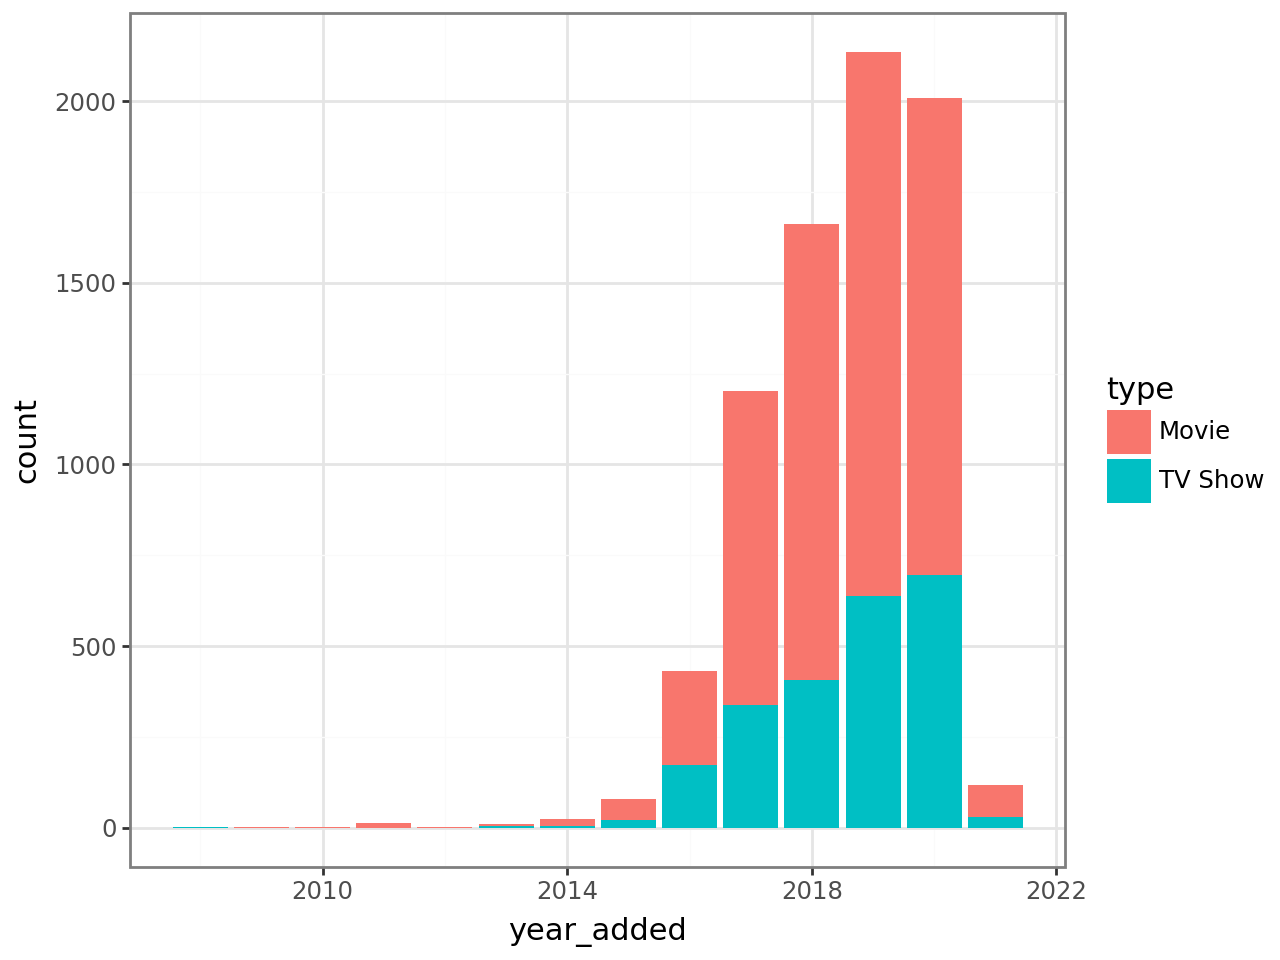

In [103]:
added_type = (netflix
 .assign(year_added = lambda d: d["date_added"].dt.year)
 .groupby(["year_added","type"]) 
 .agg(count = ("title", "count"))
 .reset_index()
)
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
)

**Task 1.1**: Change the fill colors of the bars with two colors of your choice (e.g. 'chocolate' and 'orange')

* *Hint*: use `scale_fill_manual()`
    - the first argument (`values`) accepts a list of color names or RGB hex codes (e.g. "#ff4a10")
    - it is also possible to pass a dict mapping levels of the variable to color (codes)

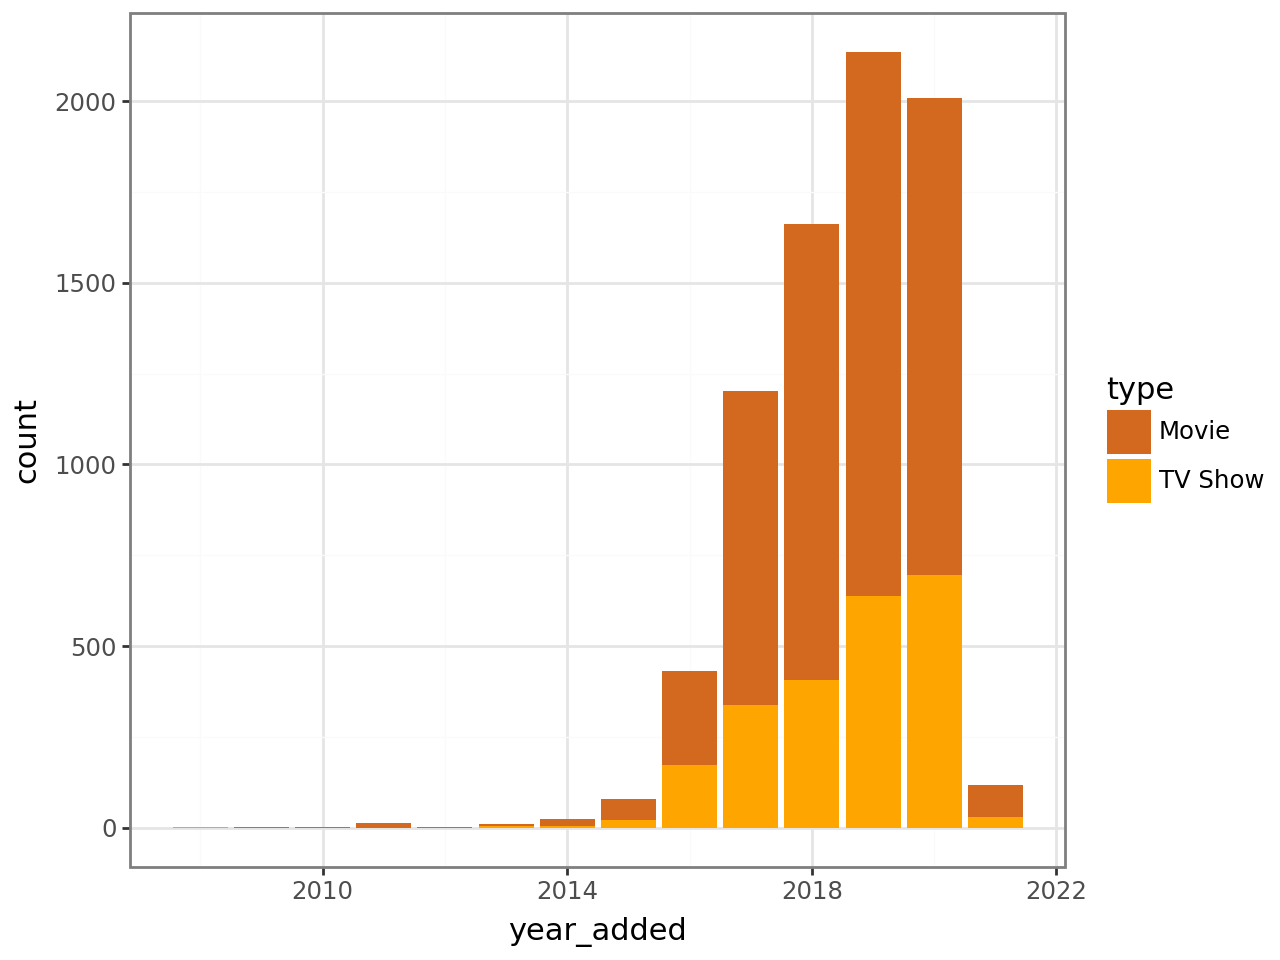

In [104]:
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
    +scale_fill_manual(values=["chocolate","orange"])
)

- **Task 1.2**: try using the predefined palettes
    - `scale_fill_brewer()`
        - parameter `type` ({`"seq", "qual", "div"`}) define the type of palette
        - parameter `palette` specifies the palette name
    - `scale_fill_cmap_d()`
        - parameter `cmap_name` specifies the name of the palette (see: [Matplotlib docs](https://matplotlib.org/stable/users/explain/colors/colormaps.html))

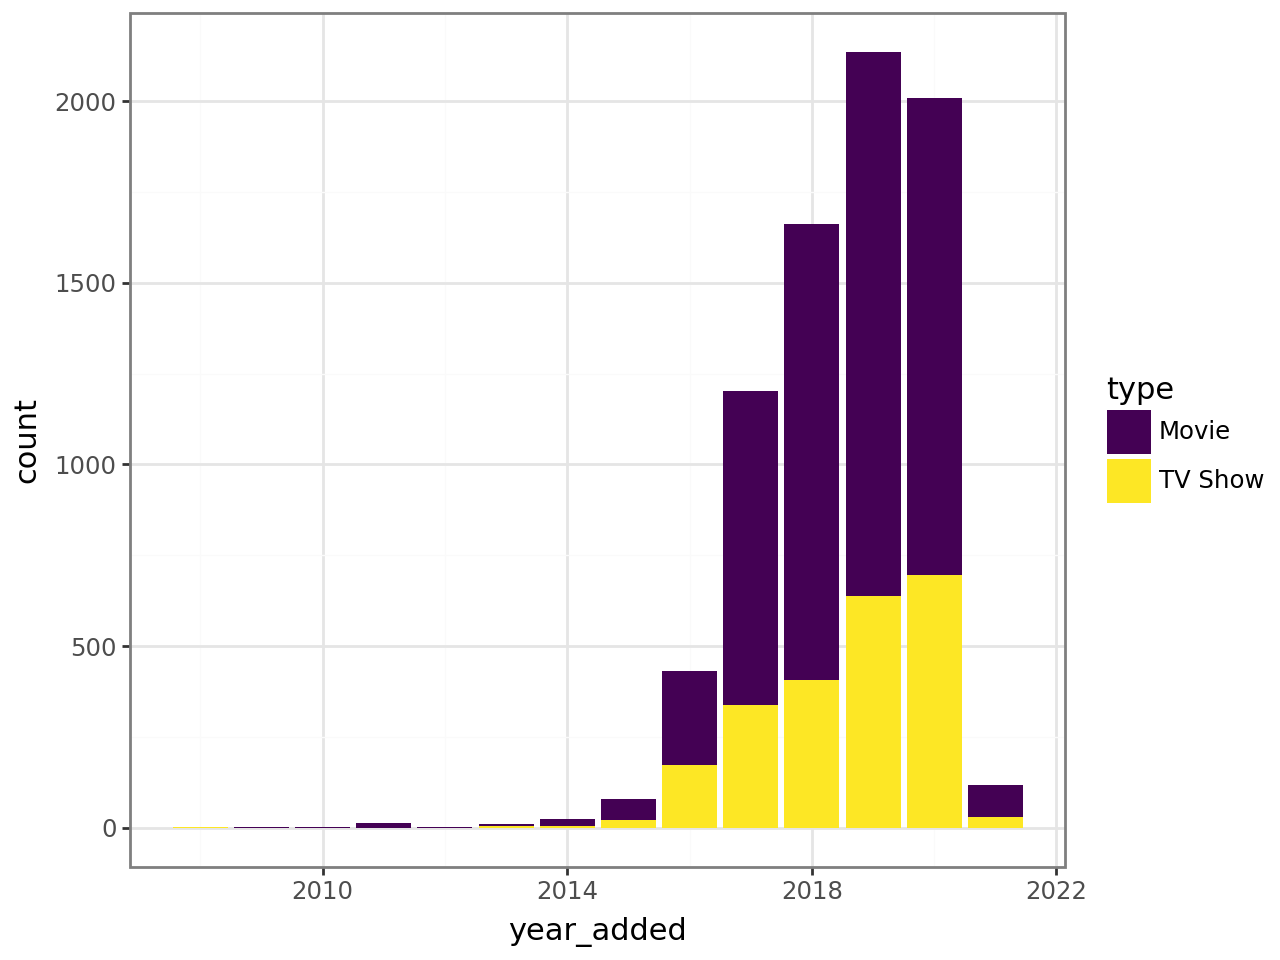

In [105]:
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
    + scale_fill_cmap_d(cmap_name="viridis")
)

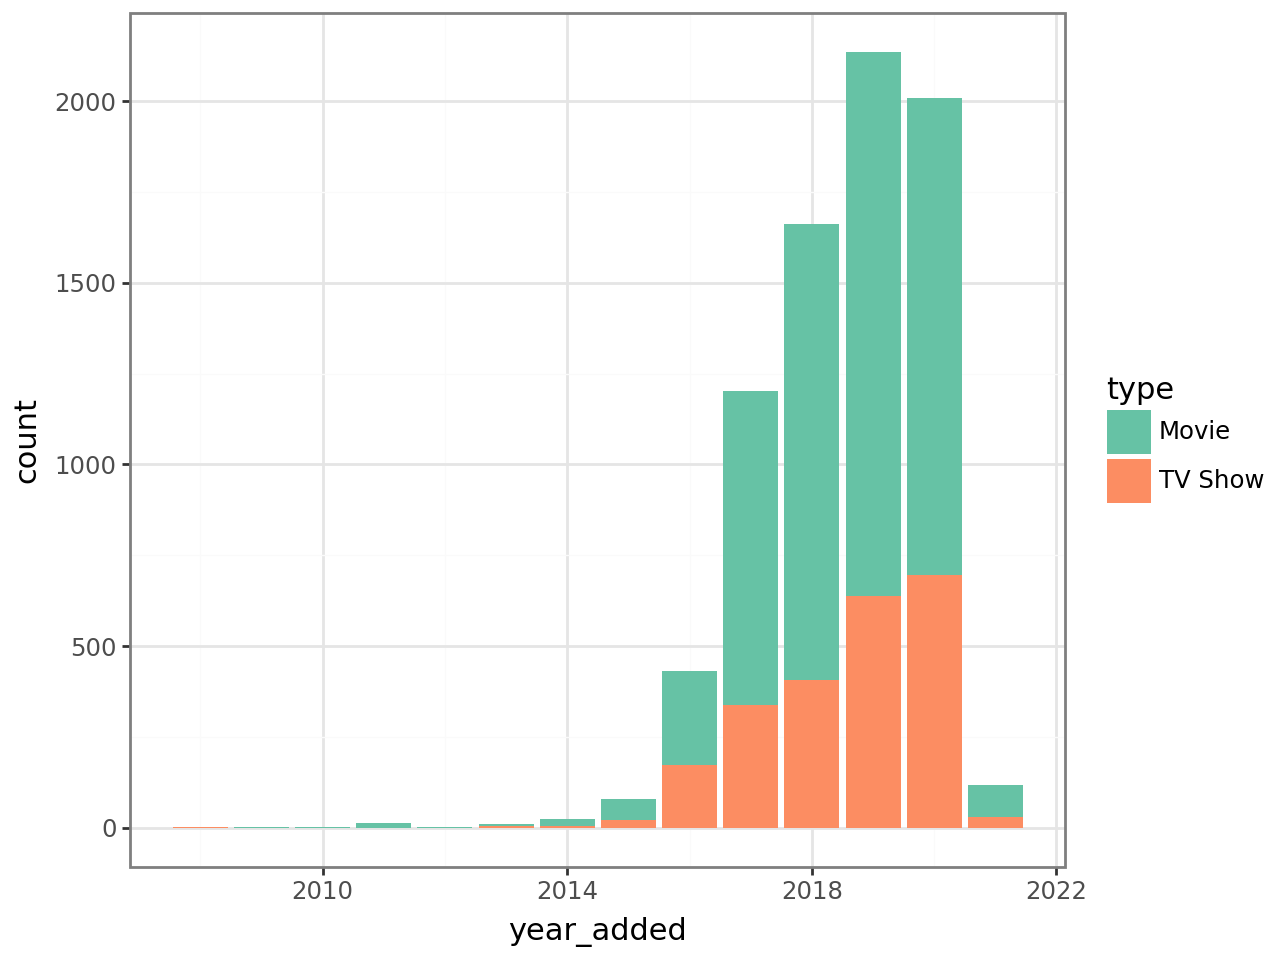

In [106]:
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
    + scale_fill_brewer(type="qual",palette="Set2")
)

**Task 1.3**: to improve clarity of the diagram split the data into two subplots (*facets*) by `type`.

* *Hint*: use `facet_wrap()` or `facet_grid()`

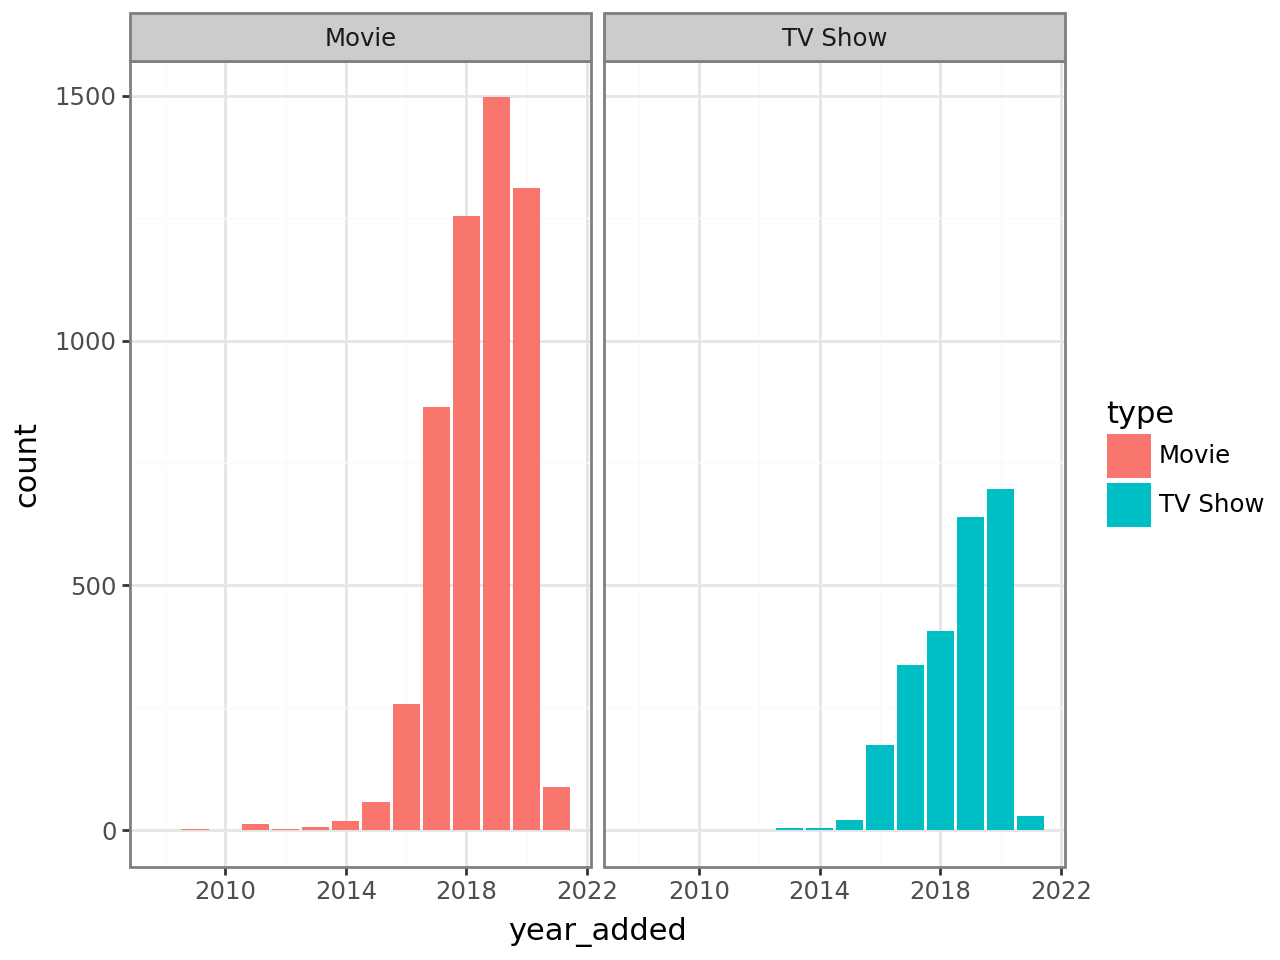

In [107]:
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
    +facet_wrap("type")
)

**Task 1.4**: since values are spread over a wide range, using a log scale could be a possible solution

* *Hint*: use `scale_y_log10()`
    - `breaks` are computed automatically
    - `minor_breaks` are not present by default, they can be useful to provide a visual hint that it is a log-scale

c:\Users\matte\Desktop\PoliTo\Data Science and  Visualization\repo_singole_labs\dsv-lab-6\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10


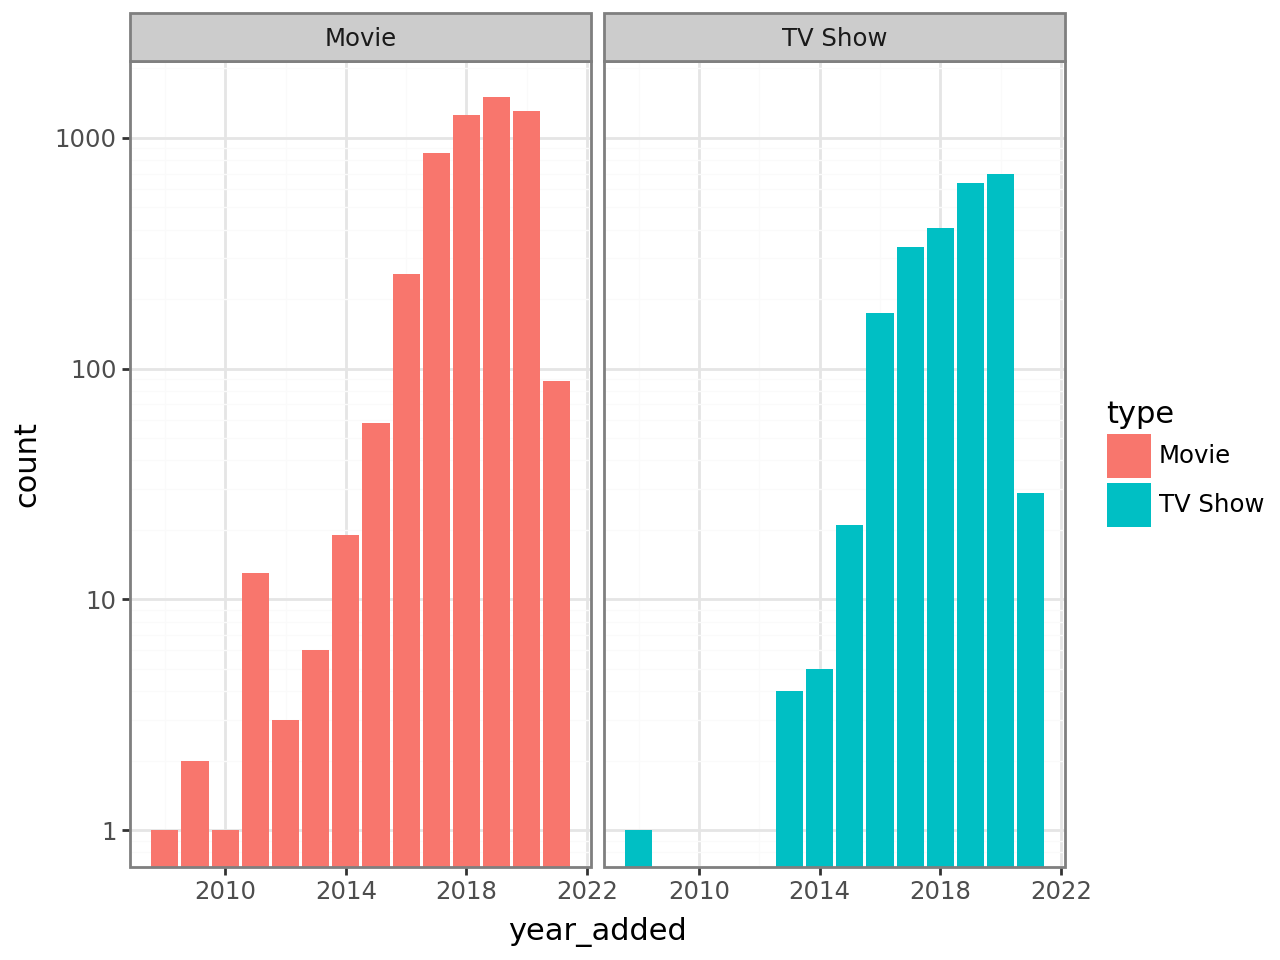

In [108]:
(
    ggplot(added_type, 
           aes(x="year_added", y="count", fill="type"))
    +geom_col()
    +theme_bw()
    +facet_wrap("type")
    +scale_y_log10()
)

## 2. Movie duration

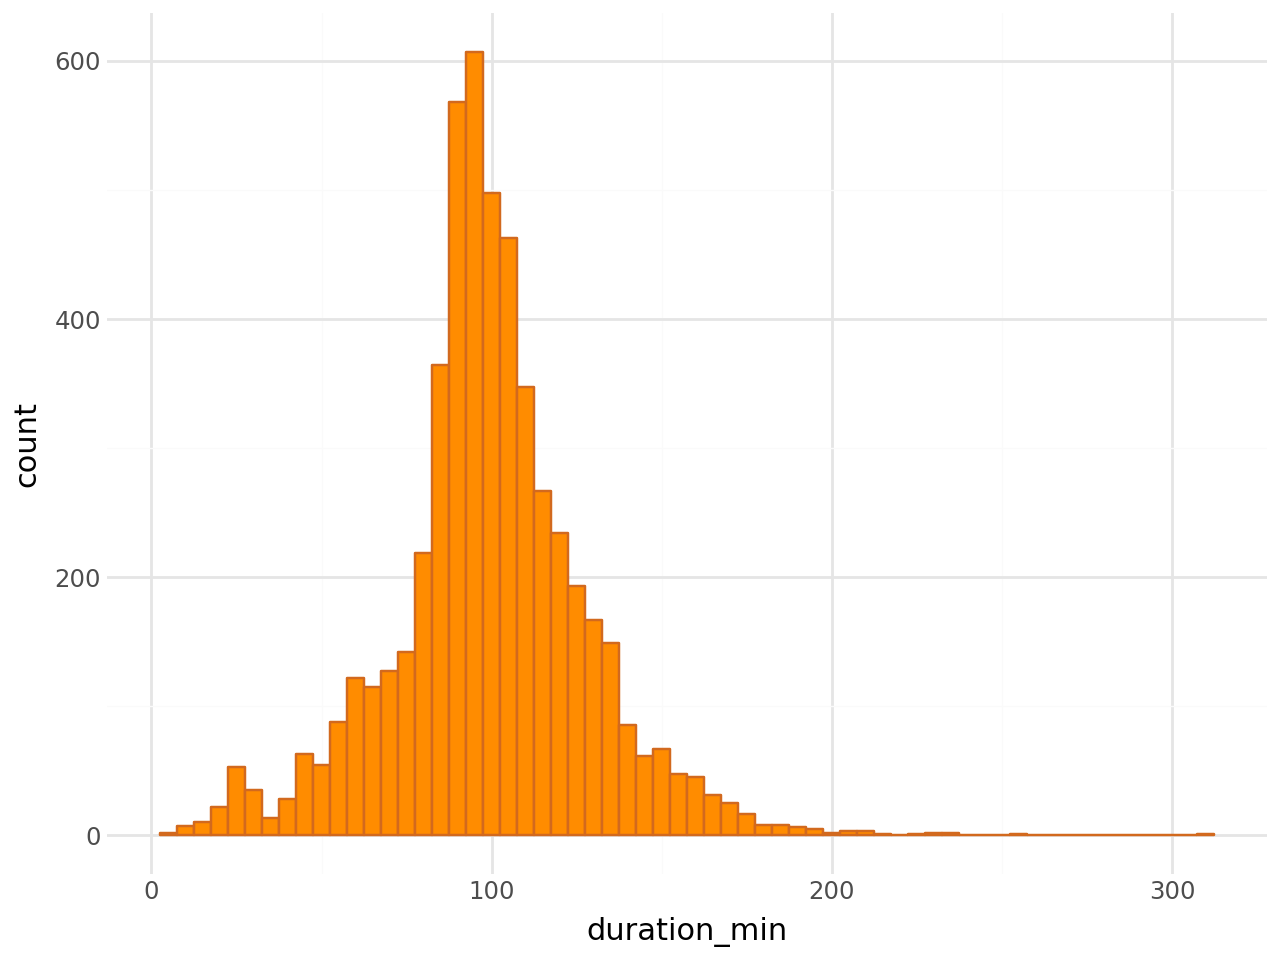

In [109]:
movie = (netflix
         [netflix["type"]=="Movie"]
         .assign(duration_min = lambda d: d["duration"].str.extract(r'(\d+)').astype(int),
                 release_decated = lambda d: (d["release_year"] // 10  *10).astype(str)
         ))
(
    ggplot(movie, aes(x="duration_min"))
    + geom_histogram(fill="darkorange", color="chocolate", binwidth=5)
    + theme_minimal()
)

The correlation of movie duration and year of release shown with a scatter plot is not telling much

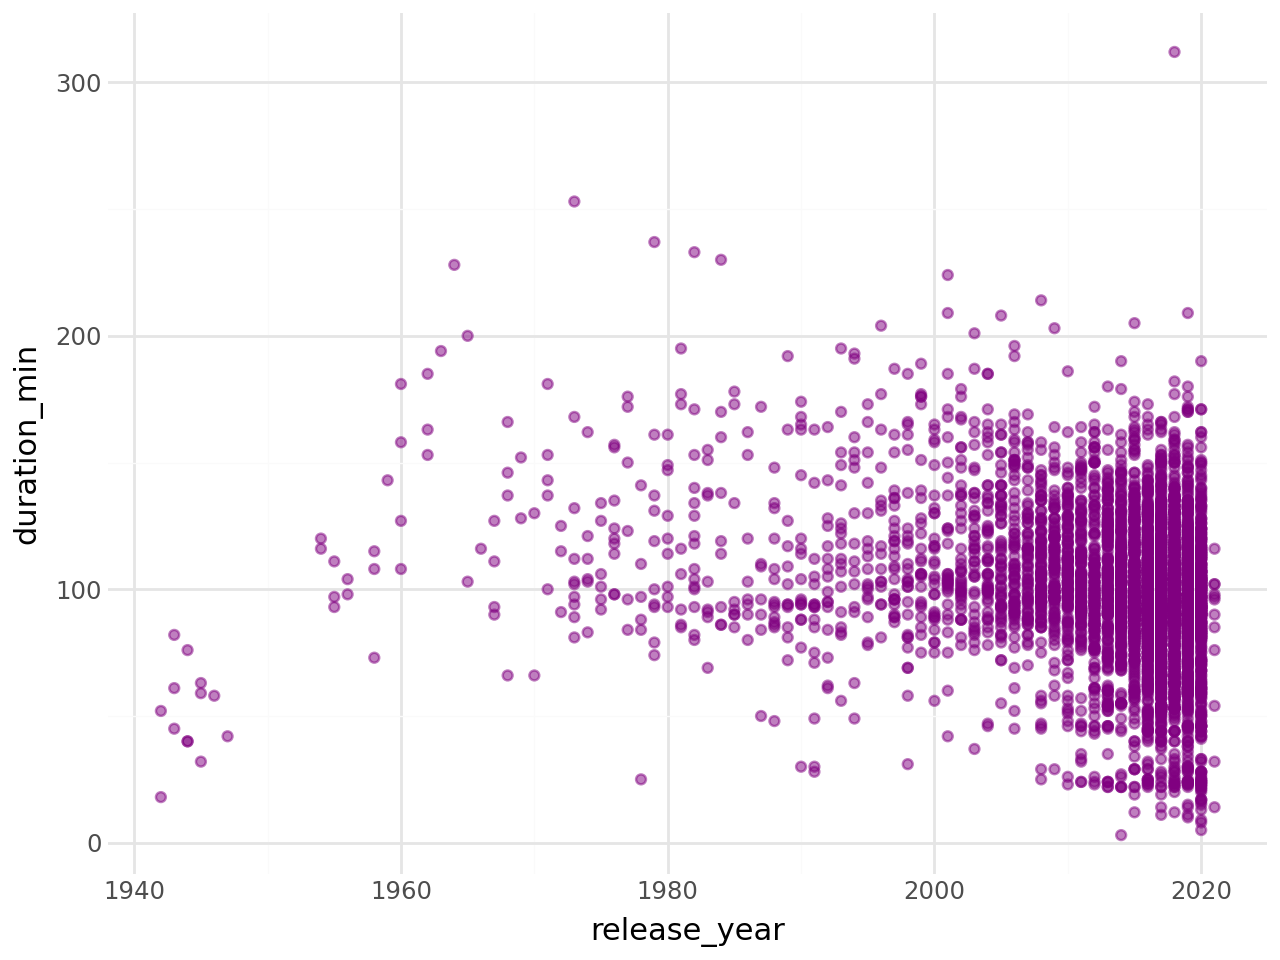

In [110]:
(
    ggplot(movie, aes(x="release_year", y="duration_min"))
    + geom_point(color="purple", alpha=0.5, shape="o")
    + theme_minimal()
)

### Duration by decade

**Task 2.1**: Show the duration by decade of release using boxplot

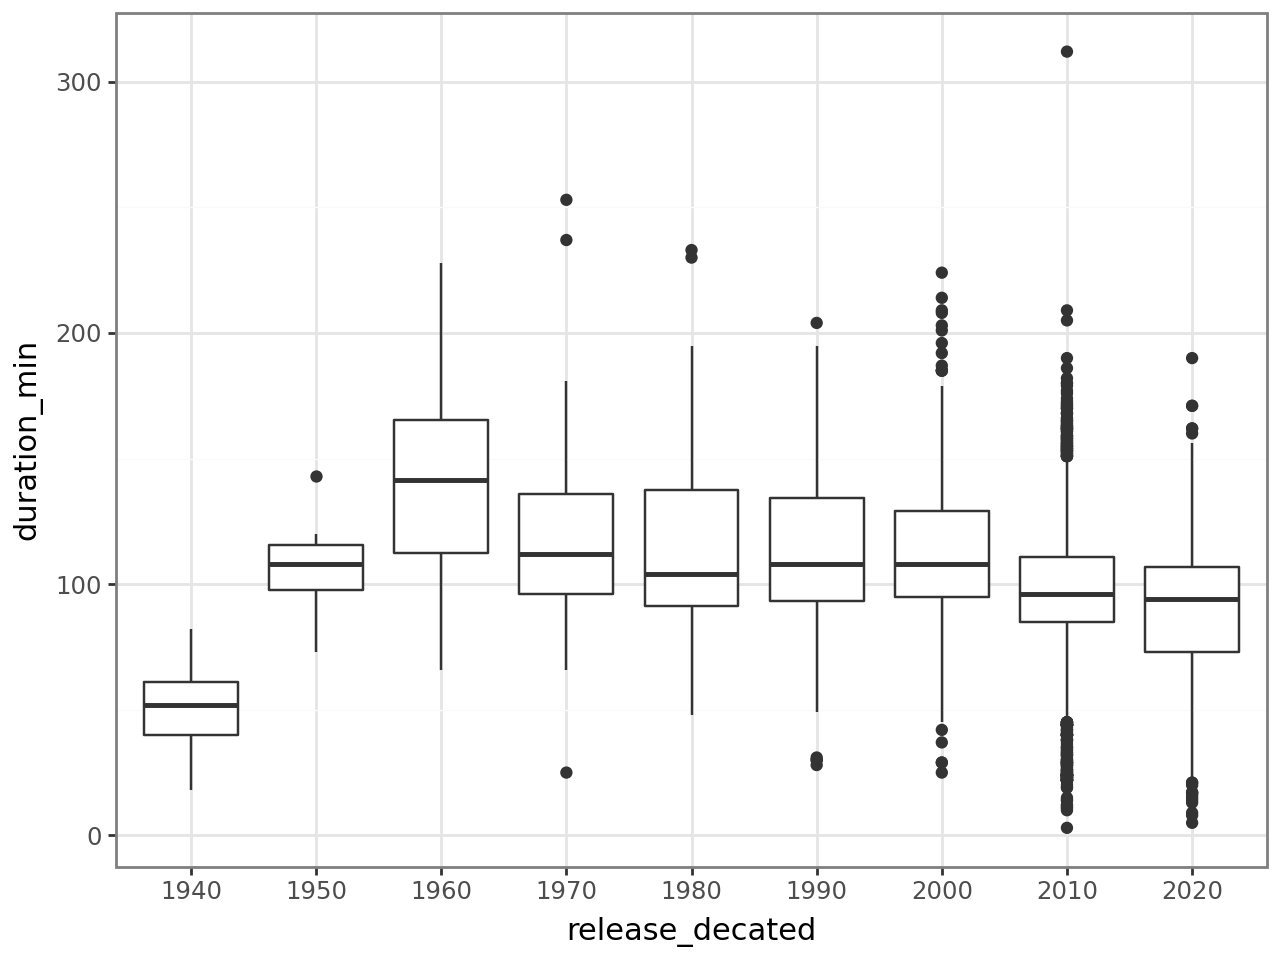

In [111]:
(
    ggplot(movie,aes(x="release_decated",y="duration_min"))
    +geom_boxplot()
    +theme_bw()
)

**Task 2.2**: Adapt the vertical axis to show "human readable" durations, such as `1h 30m` instead of `90`

* *Hint*: use `scale_y_continuous()`:
    - `breaks`: is a list of tick breaks
    - `labels`: is either a list or a function with the labels

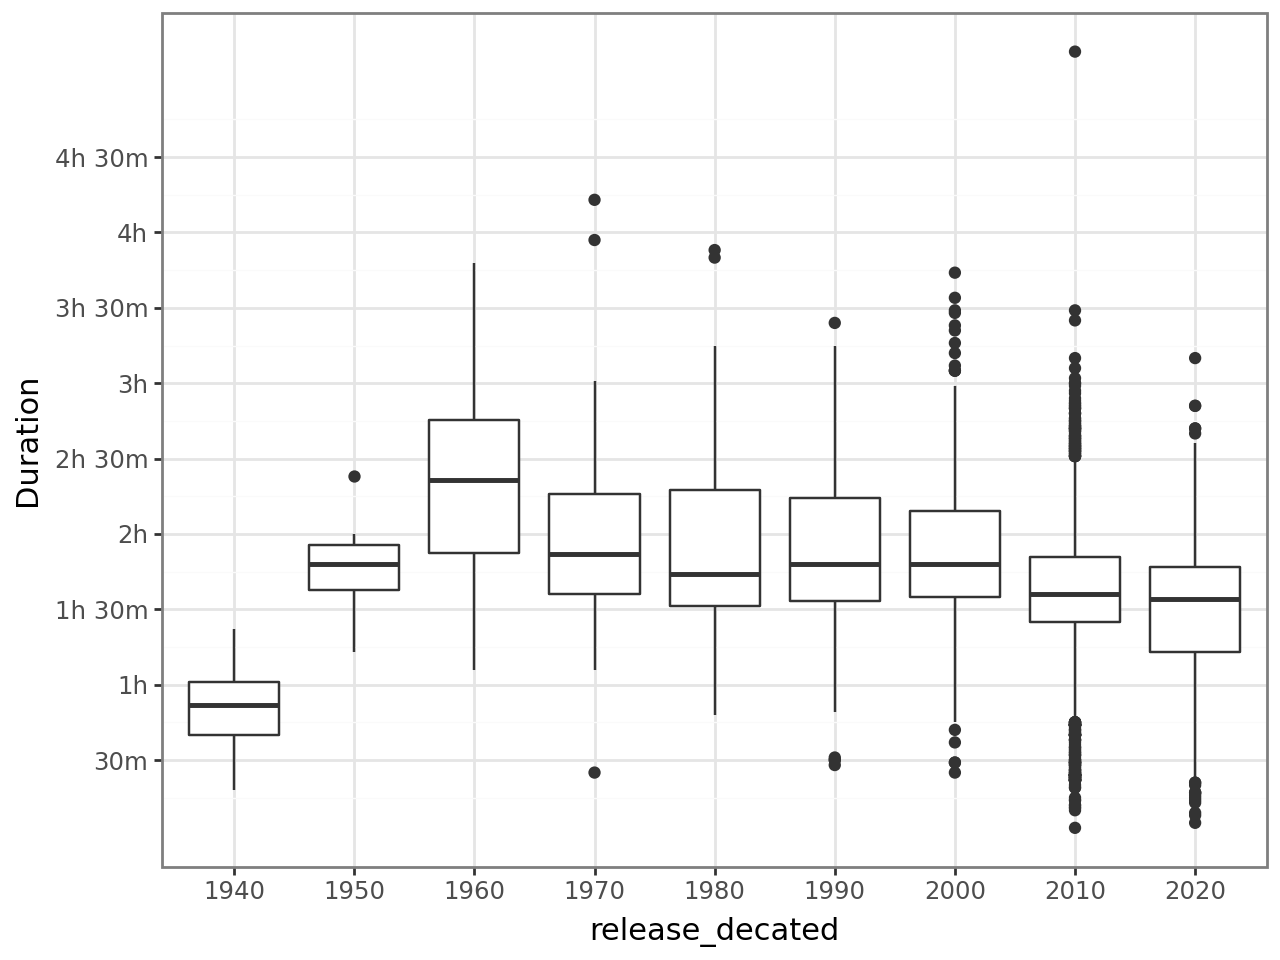

In [112]:
(
    ggplot(movie,aes(x="release_decated",y="duration_min"))
    +ylab("Duration")
    +geom_boxplot()
    +scale_y_continuous(breaks=range(30,300,30),
                        labels=["30m","1h","1h 30m","2h","2h 30m","3h","3h 30m","4h","4h 30m"])
    +theme_bw()
)

**Task 2.3**: Draw a boxplot comparing only the duration of 1990, 2000 and 2010 (horizontal or vertical?)

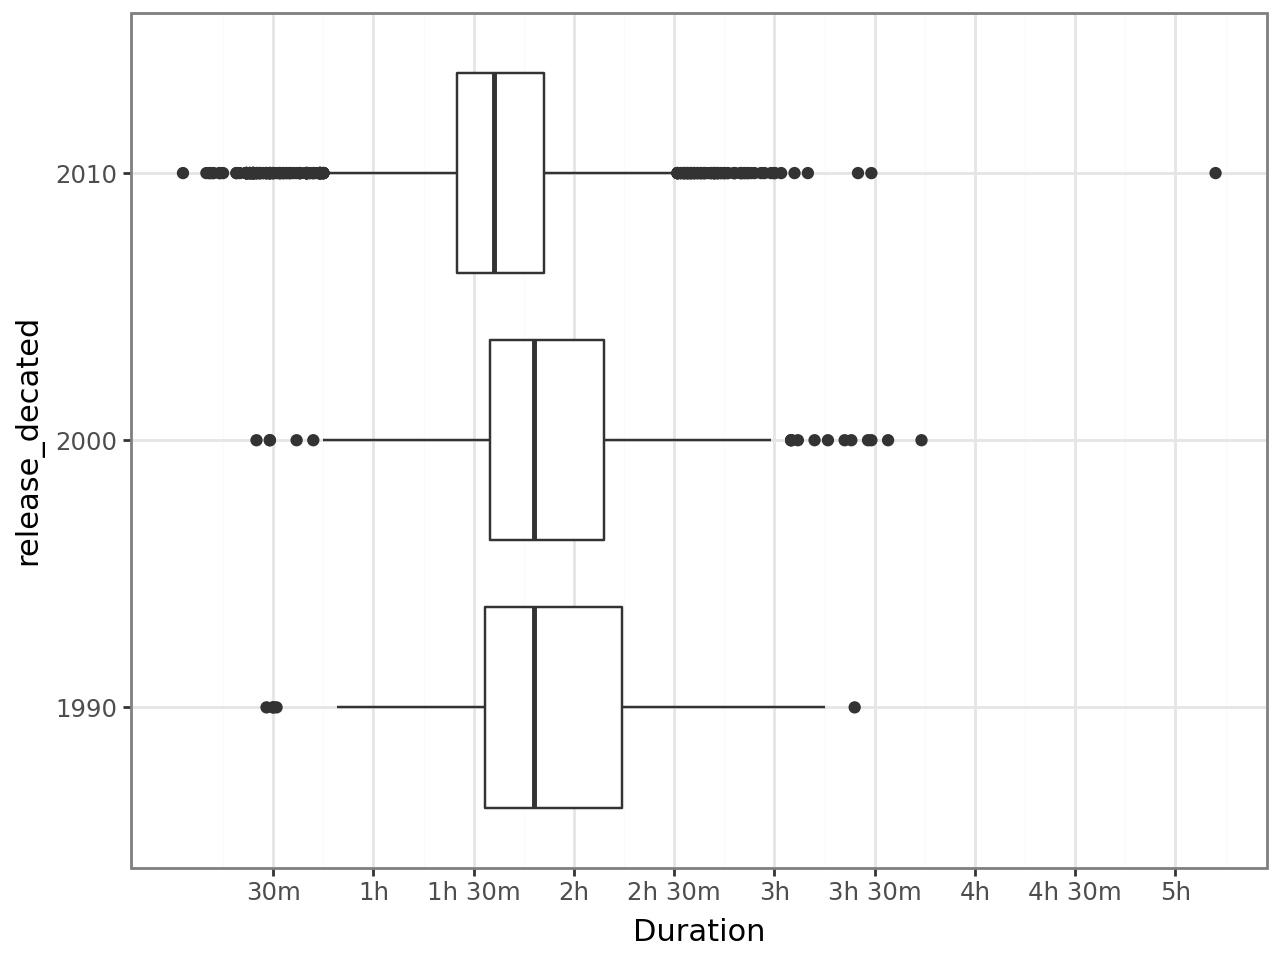

In [113]:
(
    ggplot(movie[movie["release_decated"].isin(["1990","2000","2010"])],aes(x="release_decated",y="duration_min"))
    +geom_boxplot()
    +scale_y_continuous(breaks=range(30,330,30),
                        labels=["30m","1h","1h 30m","2h","2h 30m","3h","3h 30m","4h","4h 30m","5h"])
    +coord_flip()
    +ylab("Duration")
    +theme_bw()
)

### Test differences

**Task 2.4**: Plan a test to check whether the difference in duration for film release in 1990s vs 2010s is significant.

- The null hypothesis is:

  $H_0$: $\mu_{1990s} = \mu_{2010s}$


- The confidence level is:

  95%

- The acceptable type I error ($\alpha$) is: 

   0.05


**Task 2.5**: Test the null hypothesis using a t-test


In [114]:
from scipy import stats

duration_90s = movie[movie["release_decated"]=="1990"]["duration_min"]
duration_10s = movie[movie["release_decated"]=="2010"]["duration_min"]

res_t = stats.ttest_ind(duration_90s,duration_10s)
print(f"t-statistic: {res_t.statistic:.3f}")
print(f"p-value: {res_t.pvalue:.2e}")

t-statistic: 8.836
p-value: 1.44e-18


**Can we reject the null hypothesis?**

Yes, since the p-value is lower than  $\alpha$ = 0.05

T-test is a parametric test that can be applied when the variable is normally distributed.

Are the values normally distributed?

**Task 2.6**: Perform an initial "visual" evaluation with a QQ plot

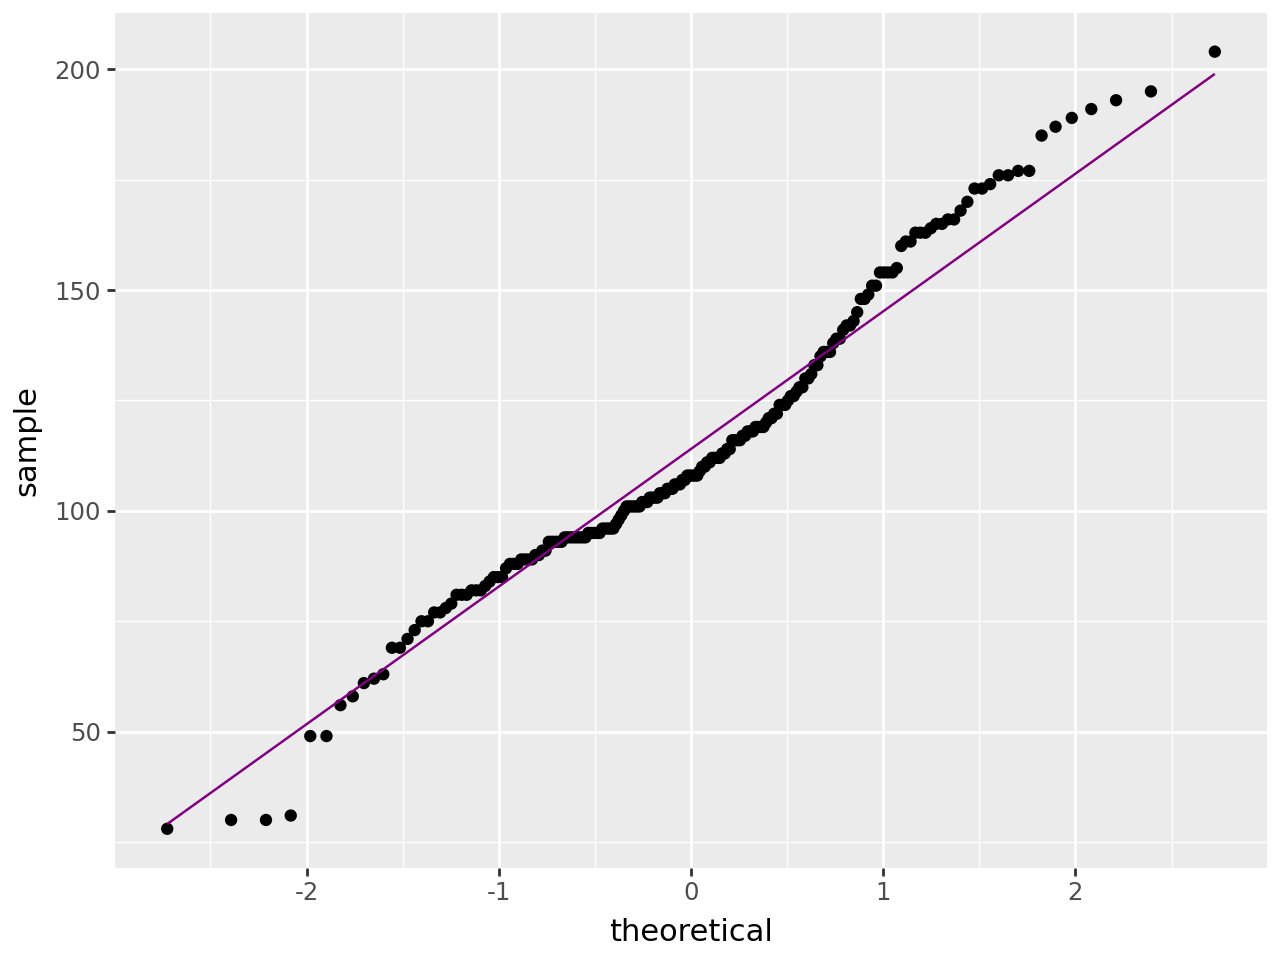

In [115]:
(
    ggplot(pd.DataFrame(duration_90s.reset_index()),aes(sample="duration_min"))
    +geom_qq()
    +geom_qq_line(color="purple")
)

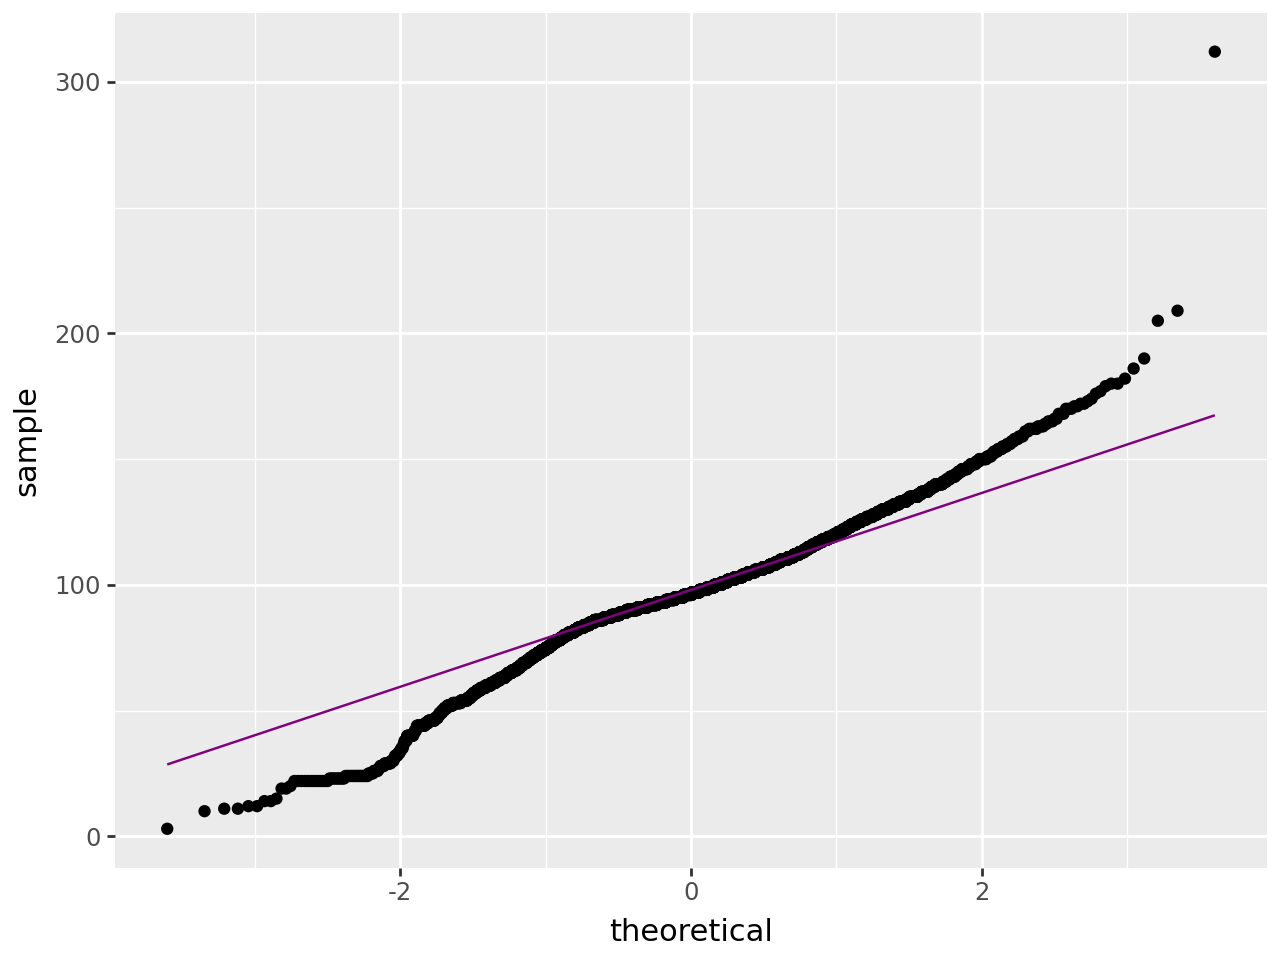

In [116]:
(
    ggplot(pd.DataFrame(duration_10s.reset_index()),aes(sample="duration_min"))
    +geom_qq()
    +geom_qq_line(color="purple")
)

Normality can be also checked with the Shapiro-Wilk (`shapiro`) test which tests the null hypothesis that the data was drawn from a normal distribution.

(p-value < 0.05 means non-normal)

**Task 2.7**: Check normality with Shapiro-Wilk 

In [117]:
res_shapiro = stats.shapiro(duration_90s)
print(f"90s p-value = {res_shapiro.pvalue}")

90s p-value = 0.0009309210986805185


In [118]:
res_shapiro = stats.shapiro(duration_10s)
print(f"10s p-value = {res_shapiro.pvalue}")

10s p-value = 2.1769792711975347e-25


Since the values are not normally distributed, a non-parametric test is advisable.

**Task 2.8**: Test the null hypothesis above using the Mann-Whitney U test

In [119]:
res_mann = stats.mannwhitneyu(duration_90s,duration_10s)
print(f"p-value = {res_mann.pvalue}")

p-value = 6.3726555458454905e-12


**Can we reject the null hypothesis?**

Yes, because p-value is lower than $\alpha$ = 0.05

### Practical vs. Statistical Difference

When a statistical hypothesis is tested we know whether there is a difference not how large it is.

**Task 2.9**: Compute the mean and median difference between the two tested samples

In [ ]:
mean_diff = duration_90s.mean() - duration_10s.mean()
median_diff = duration_90s.median() - duration_10s.median()

print(f"Mean difference = {mean_diff}")
print(f"Median difference = {median_diff}")

Mean difference = 17.155440225233335.2f
Median difference = 12.0.2f


What is the conclusion expressed in plain language terms?

The movie duration decresed by 12 o 17 minutes from the 1990s decade to the 2010s decade

**Task 2.10**: Apply the same procedure to compare 1980s to 1990s

In [123]:
# Task 2.10 - same procedure for 1980s vs 1990s
duration_80s = movie.loc[movie["release_decated"] == "1980", "duration_min"].dropna()
duration_90s_2 = movie.loc[movie["release_decated"] == "1990", "duration_min"].dropna()

res_t_80_90 = stats.ttest_ind(duration_80s, duration_90s_2)
print(f"T-test p-value (80s vs 90s): {res_t_80_90.pvalue:.3e}")

res_shapiro_80 = stats.shapiro(duration_80s)
res_shapiro_90 = stats.shapiro(duration_90s_2)
print(f"Shapiro 80s p-value: {res_shapiro_80.pvalue:.3e}")
print(f"Shapiro 90s p-value: {res_shapiro_90.pvalue:.3e}")

T-test p-value (80s vs 90s): 5.576e-01
Shapiro 80s p-value: 1.018e-05
Shapiro 90s p-value: 9.309e-04


Shapiro results guide the choice of test: if at least one p-value is lower than $\alpha = 0.05$, normality is violated and a non-parametric test is preferable.

In [124]:
res_mann_80_90 = stats.mannwhitneyu(duration_80s, duration_90s_2, alternative="two-sided")
print(f"Mann-Whitney p-value (80s vs 90s): {res_mann_80_90.pvalue:.3e}")

mean_diff_80_90 = duration_80s.mean() - duration_90s_2.mean()
median_diff_80_90 = duration_80s.median() - duration_90s_2.median()
print(f"Mean difference (80s - 90s): {mean_diff_80_90:.2f} min")
print(f"Median difference (80s - 90s): {median_diff_80_90:.2f} min")

Mann-Whitney p-value (80s vs 90s): 8.674e-01
Mean difference (80s - 90s): 2.52 min
Median difference (80s - 90s): -4.00 min


Shapiro p-values are both lower than $\alpha = 0.05$, so normality is violated and Mann-Whitney is the appropriate choice.

For Mann-Whitney, p-value = $8.674 \times 10^{-1} > 0.05$, therefore we **do not reject** $H_0$.
In this context, $H_0$ means no significant difference in the distributions (or central tendency) of movie duration between 1980s and 1990s.

----

Last update: 2026-04-23